<a href="https://colab.research.google.com/github/Afrin-mte/OIBSIP/blob/main/Task_04(Dataset_1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Sentiment Analysis on a Twitter Dataset**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wordcloud as WordCloud
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
nltk.download('stopwords')
stop_words=set(stopwords.words('english'))
sns.set_theme(style='darkgrid')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


**Data Loading and Initial Visualization**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115008 entries, 0 to 115007
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  115007 non-null  object 
 1   category    115007 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.8+ MB
(115008, 2)


/tmp/ipykernel_2743/729129402.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='category', data=df, palette='viridis')


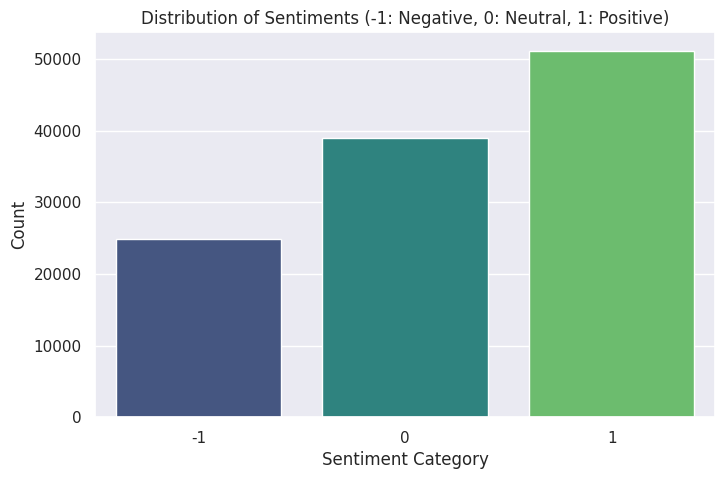

In [3]:
df=pd.read_csv('Twitter_Data.csv')
df.info()
print(df.shape)
df.head()
df.dropna(subset=['clean_text', 'category'], inplace=True)
df['category'] = df['category'].astype(int)
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='category', data=df, palette='viridis')
plt.title('Distribution of Sentiments (-1: Negative, 0: Neutral, 1: Positive)')
plt.xlabel('Sentiment Category')
plt.ylabel('Count')
plt.show()

**Feature engineering and NLP preprocessing**

In [ ]:
import re
def preprocess_text(text):
  text= str(text).lower()#lowercase
  text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
  text = re.sub(r'\@\w+|\#','', text) # Remove mentions and hashtags
  text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
  # Remove stopwords
  text = " ".join([word for word in text.split() if word not in stop_words])
  return text
print("applying NLP Process..........")
df['processed_text']=df['clean_text'].apply(preprocess_text)
X_train,X_test,y_train,y_test=train_test_split(df['processed_text'],df['category'],test_size=0.2,random_state=42)
vectorizer=TfidfVectorizer(max_features=15000,ngram_range=(1,2))
X_train_vec=vectorizer.fit_transform(X_train)
X_test_vec=vectorizer.transform(X_test)
print(f"Feature engineering complete .... Extracted {X_train_vec.shape[1]} features")

applying NLP Process..........


**Naive Bayes and SVM**

In [ ]:
print("Training naive bayes model........")
nb_model= MultinomialNB()
nb_model.fit(X_train_vec,y_train)
nb_model.predict(X_test_vec)
y_pred=nb_model.predict(X_test_vec)
print("Training SVM model........")
svm_model= LinearSVC(max_iter=2000,random_state=42)
svm_model.fit(X_train_vec,y_train)
svm_pred=svm_model.predict(X_test_vec)
print("models trained successfully")

**Reports**

SVM Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.79      0.83      4950
     Neutral       0.88      0.96      0.92      7860
    Positive       0.92      0.90      0.91     10192

    accuracy                           0.90     23002
   macro avg       0.89      0.88      0.89     23002
weighted avg       0.90      0.90      0.90     23002



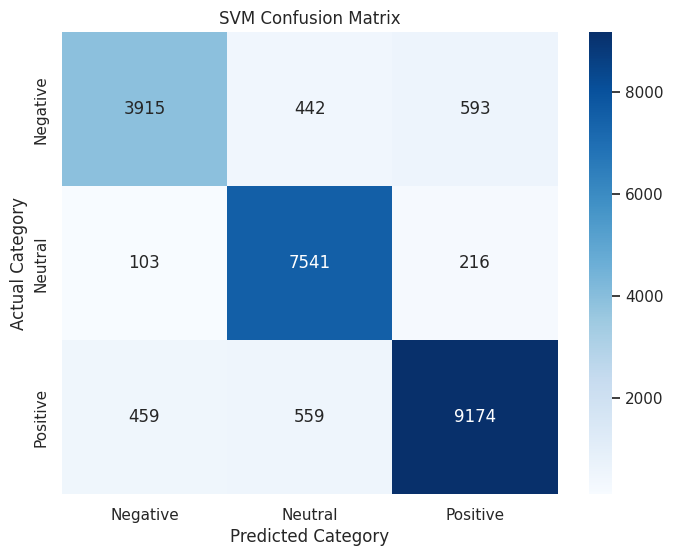

In [6]:
print("SVM Classification Report:")
print(classification_report(y_test, svm_pred, target_names=['Negative', 'Neutral', 'Positive']))

# Visualization 2: Confusion Matrix
cm = confusion_matrix(y_test, svm_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.title('SVM Confusion Matrix')
plt.show()

**WordCloud visualization**

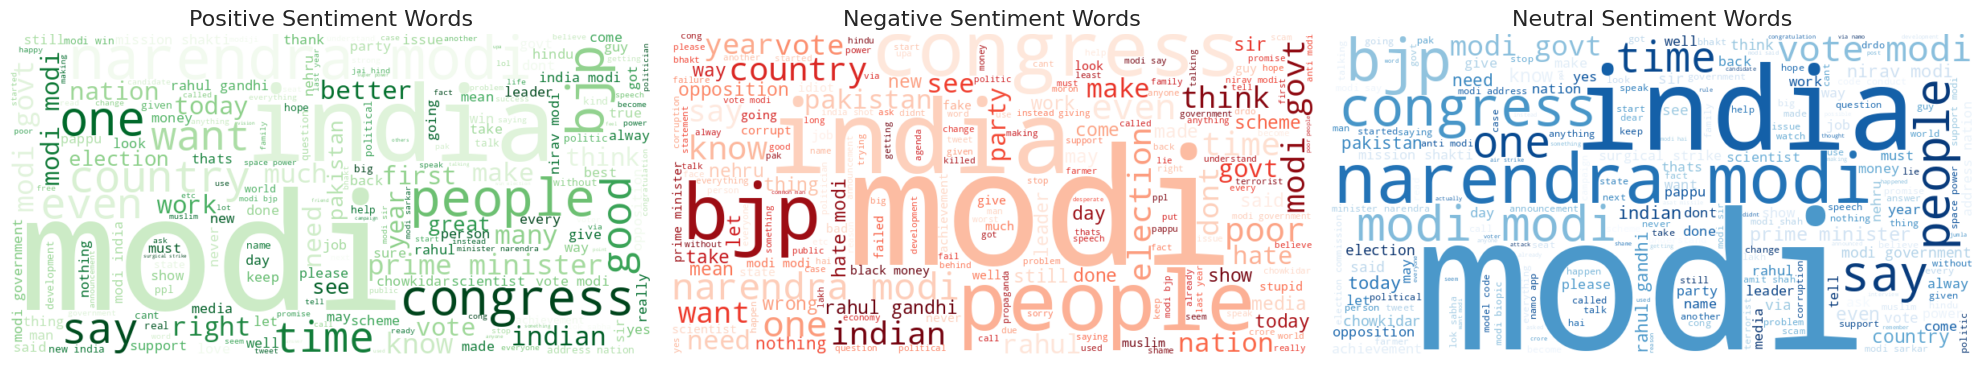

In [7]:
#seperating text by sentiment
positive_text= " ".join(df[df['category']==1]['processed_text'])
negative_text= " ".join(df[df['category']==-1]['processed_text'])
neutral_text= " ".join(df[df['category']==0]['processed_text'])

# Fixed: changed 1, 2 to 1, 3 to accommodate 3 wordclouds
fig, ax = plt.subplots(1, 3, figsize=(20, 8))

wordcloud_pos= WordCloud.WordCloud(width=800, height=400, background_color='white', colormap= "Greens").generate(positive_text)
ax[0].imshow(wordcloud_pos, interpolation='bilinear')
ax[0].set_title('Positive Sentiment Words', fontsize=16)
ax[0].axis('off')

wordcloud_neg= WordCloud.WordCloud(width=800, height=400, background_color='white', colormap= "Reds").generate(negative_text)
ax[1].imshow(wordcloud_neg, interpolation='bilinear')
ax[1].set_title('Negative Sentiment Words', fontsize=16)
ax[1].axis('off')

wordcloud_neu= WordCloud.WordCloud(width=800, height=400, background_color='white', colormap= "Blues").generate(neutral_text)
ax[2].imshow(wordcloud_neu, interpolation='bilinear')
ax[2].set_title('Neutral Sentiment Words', fontsize=16)
ax[2].axis('off')

plt.tight_layout()
plt.show()